In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("student_performance.csv")

In [3]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [25]:
df =df.drop(columns = ['math_score','science_score','english_score','final_grade'])

In [26]:
df['study_method'].value_counts()

study_method
mixed            2602
textbook         2546
notes            2515
online videos    2468
group study      2447
coaching         2422
Name: count, dtype: int64

In [27]:
df.shape

(15000, 12)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             15000 non-null  int64  
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   school_type            15000 non-null  object 
 4   parent_education       15000 non-null  object 
 5   study_hours            15000 non-null  float64
 6   attendance_percentage  15000 non-null  float64
 7   internet_access        15000 non-null  object 
 8   travel_time            15000 non-null  object 
 9   extra_activities       15000 non-null  object 
 10  study_method           15000 non-null  object 
 11  overall_score          15000 non-null  float64
dtypes: float64(3), int64(2), object(7)
memory usage: 1.5+ MB


In [29]:
df.describe()

,student_id,age,study_hours,attendance_percentage,overall_score
count,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000
mean,7500.500000,16.476400,4.25936,74.991760,64.015500
std,4330.271354,1.704475,2.17244,14.401139,18.977811
min,1.000000,14.000000,0.50000,50.000000,14.500000
25%,3750.750000,15.000000,2.40000,62.600000,49.000000
50%,7500.500000,16.000000,4.30000,75.000000,64.300000
75%,11250.250000,18.000000,6.10000,87.400000,79.100000
max,15000.000000,19.000000,8.00000,100.000000,100.000000


# target variable analysis

In [30]:
import seaborn as sns 
import matplotlib.pyplot as plt

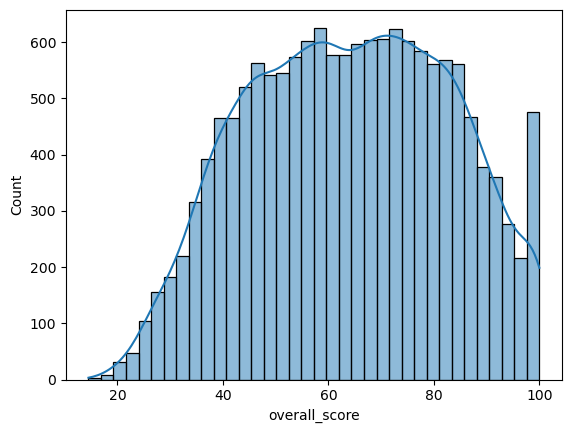

In [31]:
sns.histplot(df['overall_score'], kde = True)
plt.show()

# numerical features analysis

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'study_hours'}>],
       [<Axes: title={'center': 'attendance_percentage'}>, <Axes: >]],
      dtype=object)

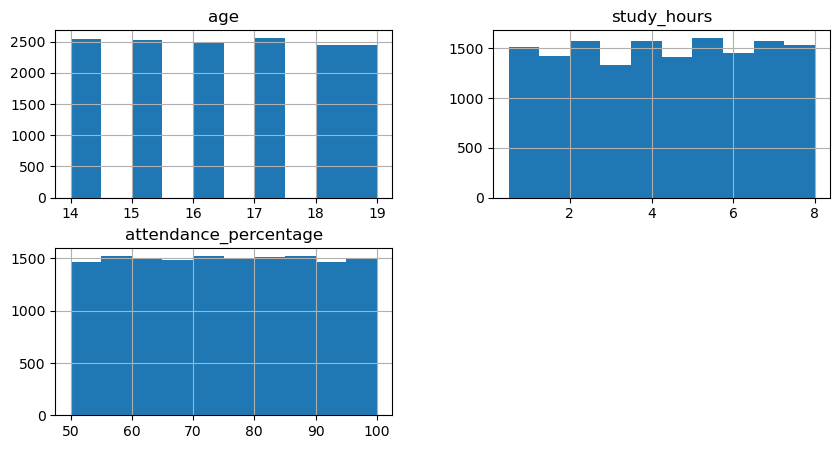

In [32]:
df[['age','study_hours','attendance_percentage']].hist(figsize=(10,5))


# correlation heatmap

<Axes: >

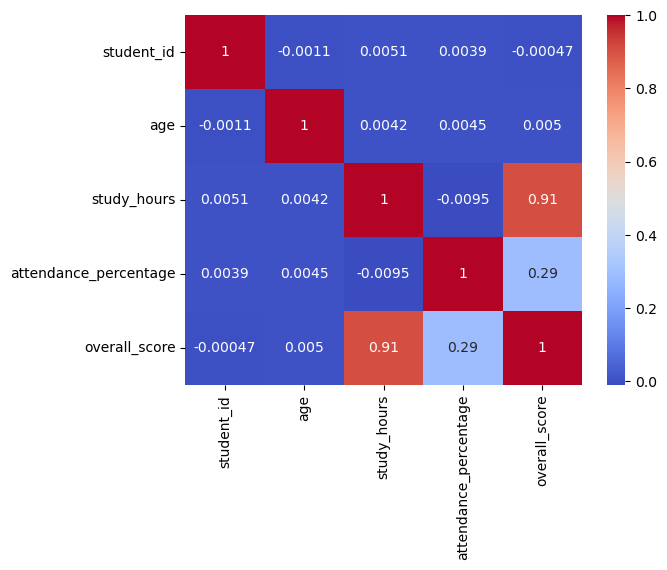

In [33]:
sns.heatmap(df.corr(numeric_only=True),annot = True, cmap = "coolwarm")

# categorical features analysis

<Axes: xlabel='gender', ylabel='count'>

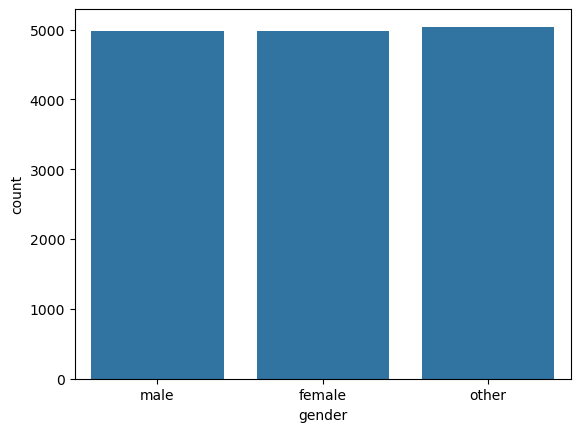

In [34]:
sns.countplot(x = 'gender',data = df)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'post graduate'),
  Text(1, 0, 'graduate'),
  Text(2, 0, 'high school'),
  Text(3, 0, 'no formal'),
  Text(4, 0, 'diploma'),
  Text(5, 0, 'phd')])

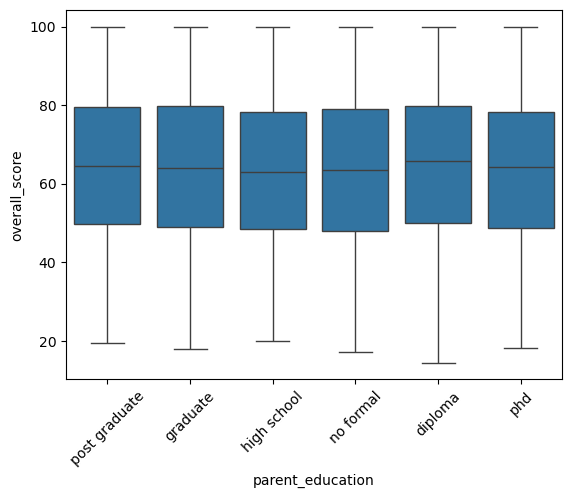

In [35]:
sns.boxplot(x = 'parent_education', y = 'overall_score', data = df)
plt.xticks(rotation = 45)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'notes'),
  Text(1, 0, 'textbook'),
  Text(2, 0, 'group study'),
  Text(3, 0, 'coaching'),
  Text(4, 0, 'mixed'),
  Text(5, 0, 'online videos')])

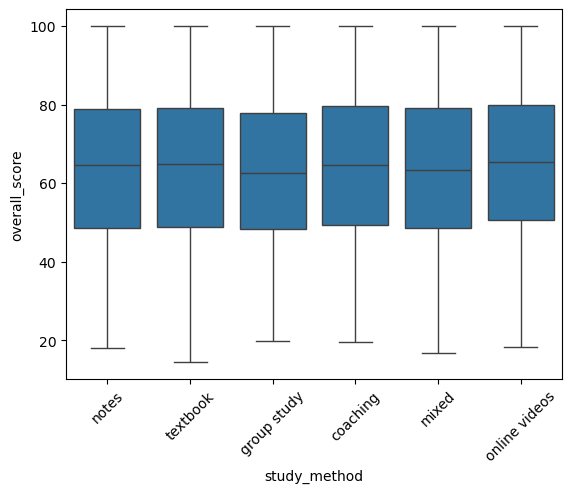

In [36]:
sns.boxplot(x = 'study_method', y = 'overall_score', data = df)
plt.xticks(rotation = 45)

# outlier detection

<Axes: ylabel='overall_score'>

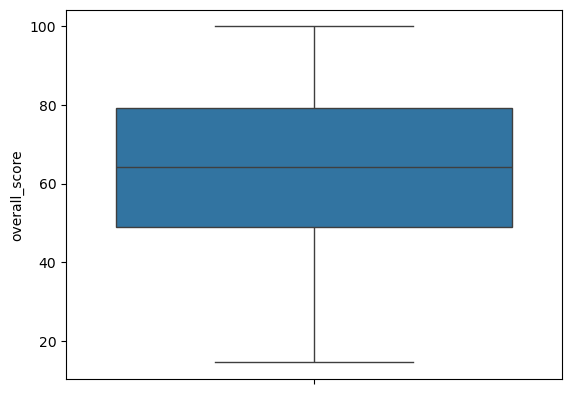

In [37]:
sns.boxplot(df['overall_score'])

# group analysis

In [38]:
df.groupby("study_method")["overall_score"].mean()

study_method
coaching         64.476259
group study      63.251287
mixed            63.653574
notes            63.858012
online videos    64.683063
textbook         64.190024
Name: overall_score, dtype: float64

In [39]:
df.groupby("parent_education")["overall_score"].mean()

parent_education
diploma          64.773382
graduate         63.946393
high school      63.445972
no formal        63.653006
phd              63.938417
post graduate    64.303748
Name: overall_score, dtype: float64

In [40]:
df.corr(numeric_only=True)['overall_score'].sort_values(ascending = False)

overall_score            1.000000
study_hours              0.905885
attendance_percentage    0.288473
age                      0.004981
student_id              -0.000468
Name: overall_score, dtype: float64